In [41]:
# ==========================================
# 🔥 FINAL PREPROCESSING PIPELINE (KAGGLE)
# ==========================================

# 1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 2. Load Dataset
df = pd.read_csv("/kaggle/input/datasets/chandanmaji/heart-new/heart.csv")

In [42]:
# 3. Basic Check
print("Shape:", df.shape)
print(df.isnull().sum())
print(df.head(10))

Shape: (1025, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   
5   58    0   0       100   248    0        0      122      0      1.0      1   
6   58    1   0       114   318    0        2      140      0      4.4      0   
7   55    1   0       160   289    0        0      145      1      0.8      1   
8   46    1   0       120   249    0        

In [43]:
# 4. Split Features & Target
X = df.drop("target", axis=1)
y = df["target"]

In [44]:
# 5. Define Column Types

# Binary features (0/1)
binary_cols = [
    'sex'
]

# Categorical (multi-class)
#categorical_cols = ['education']

# Numerical features
numerical_cols = [
    'age', 'cp', 'trestbps',
    'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal' ]

In [46]:
# 6. Pipelines

# Numerical Pipeline → KNN Imputer + Scaling
num_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])



# Binary Pipeline → Most frequent imputation
bin_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [47]:
# 7. Combine All
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('bin', bin_pipeline, binary_cols)
])

In [76]:
# 8. Train-Test Split (VERY IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
# 9. Apply Preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [63]:
# 10. Output Check
print("Original shape:", X_train.shape)
print("Processed shape:", X_train_processed.shape)

Original shape: (820, 13)
Processed shape: (820, 13)


In [51]:
# Optional: Convert to DataFrame (for visualization/debugging)
X_train_processed_df = pd.DataFrame(X_train_processed)
X_test_processed_df = pd.DataFrame(X_test_processed)

print("Preprocessing Done ✅")

Preprocessing Done ✅


In [62]:

smote = SMOTE(
    sampling_strategy={0: 1000, 1: 1000},
    random_state=42,
    k_neighbors=5
)

X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

In [65]:
# 10. Output Check
print("Original shape:", X_train.shape)
print("Processed shape:", X_train_res.shape)

Original shape: (820, 13)
Processed shape: (2000, 13)


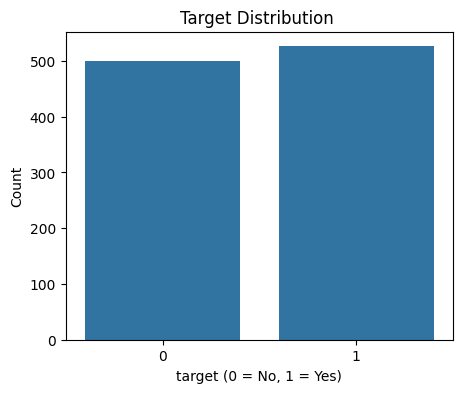

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("Target Distribution ")
plt.xlabel("target (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print(df['target'].value_counts(normalize=True))

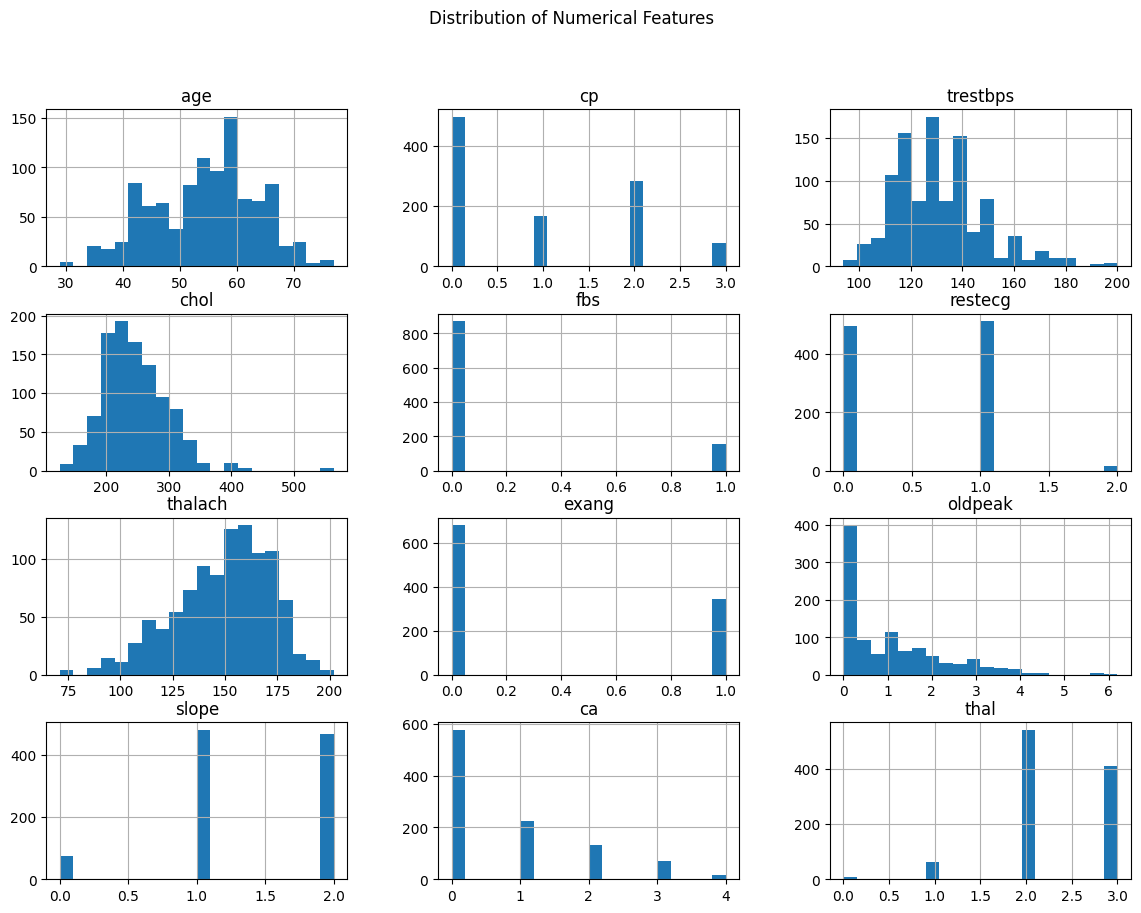

In [67]:



df[numerical_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

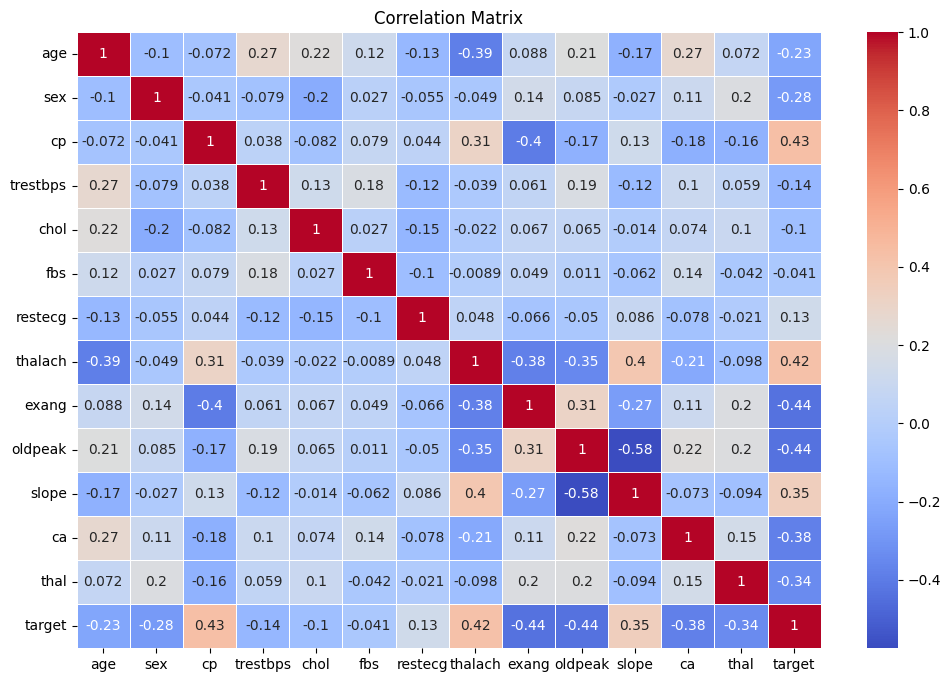

In [68]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', annot=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

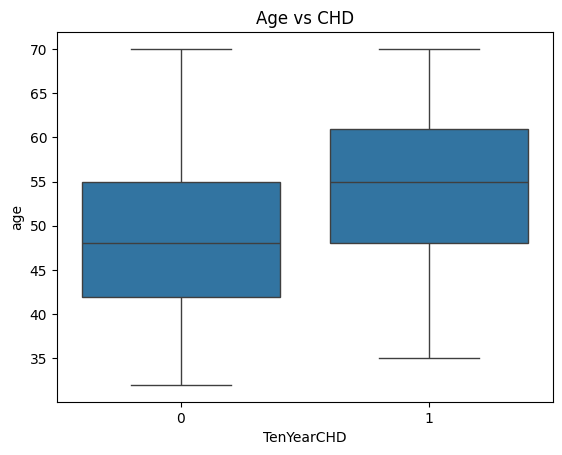

In [17]:
sns.boxplot(x='TenYearCHD', y='age', data=df)
plt.title("Age vs CHD")
plt.show()

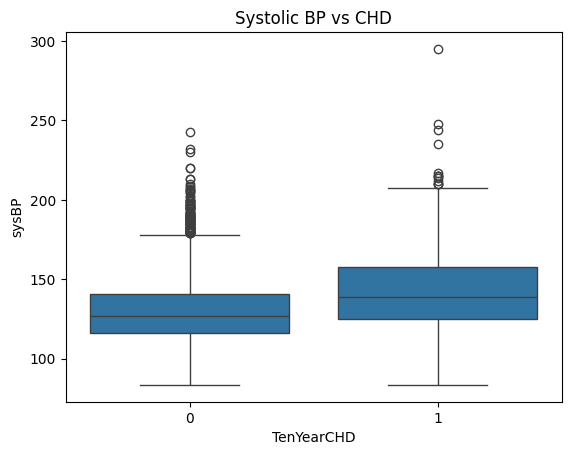

In [18]:
sns.boxplot(x='TenYearCHD', y='sysBP', data=df)
plt.title("Systolic BP vs CHD")
plt.show()

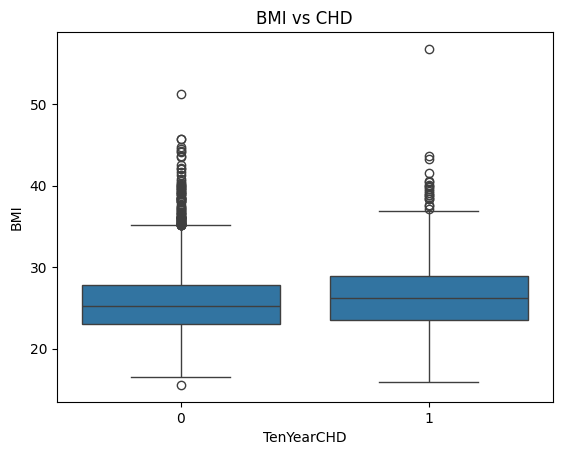

In [20]:
sns.boxplot(x='TenYearCHD', y='BMI', data=df)
plt.title("BMI vs CHD")
plt.show()

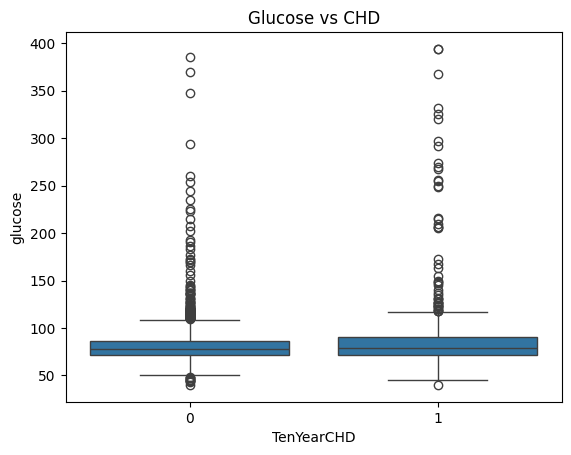

In [21]:
sns.boxplot(x='TenYearCHD', y='glucose', data=df)
plt.title("Glucose vs CHD")
plt.show()

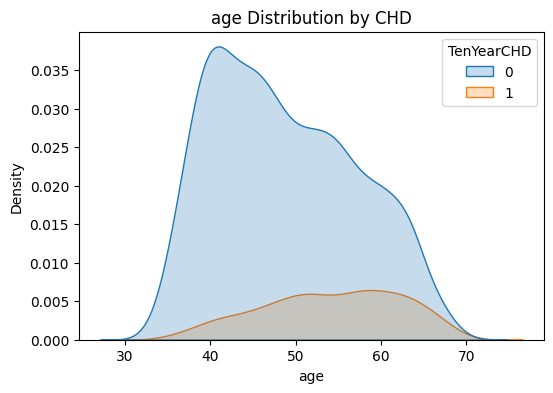

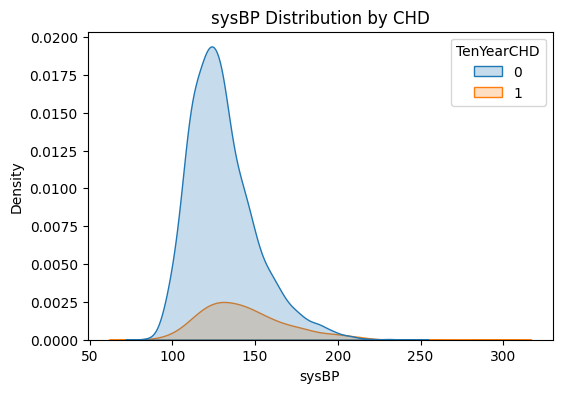

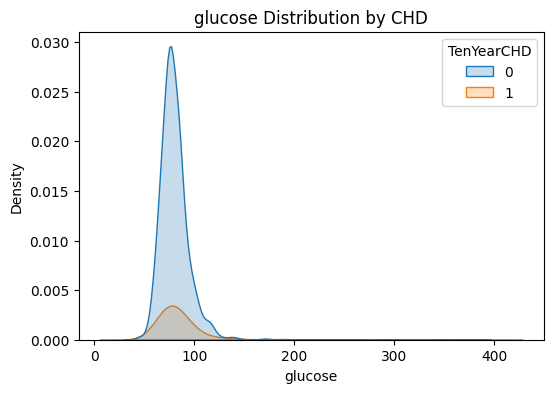

In [22]:
for col in ['age', 'sysBP', 'glucose']:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue='TenYearCHD', fill=True)
    plt.title(f"{col} Distribution by CHD")
    plt.show()

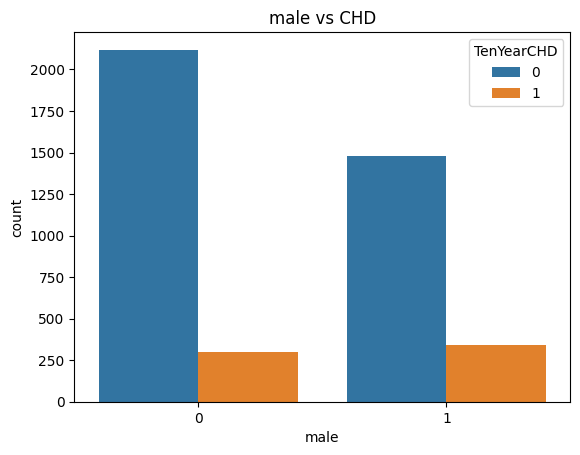

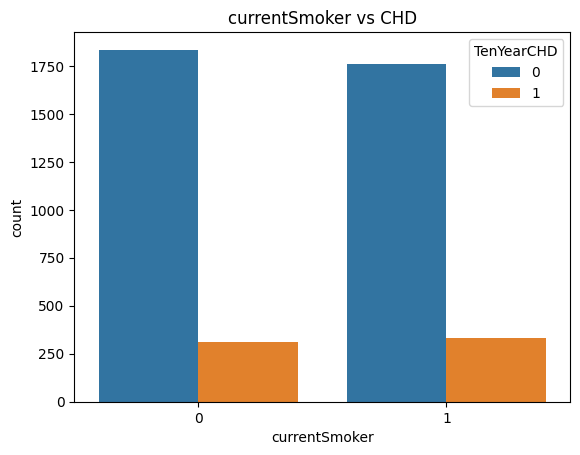

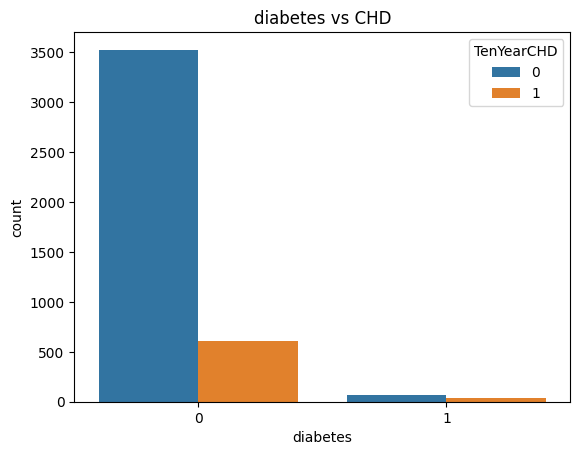

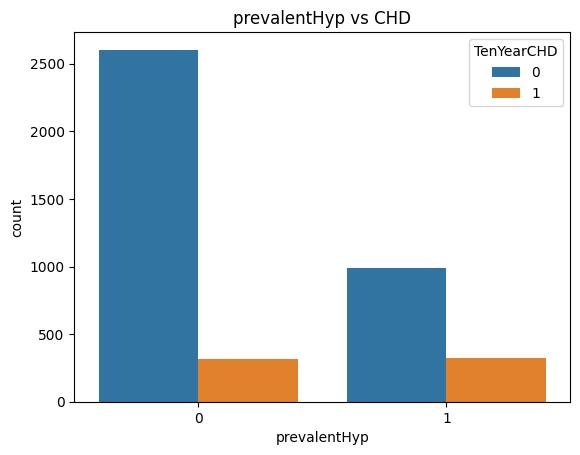

In [23]:
cat_cols = ['male', 'currentSmoker', 'diabetes', 'prevalentHyp']

for col in cat_cols:
    sns.countplot(x=col, hue='TenYearCHD', data=df)
    plt.title(f"{col} vs CHD")
    plt.show()

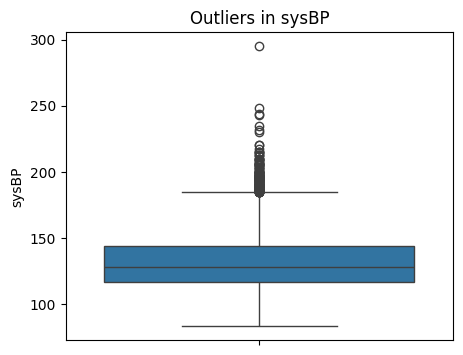

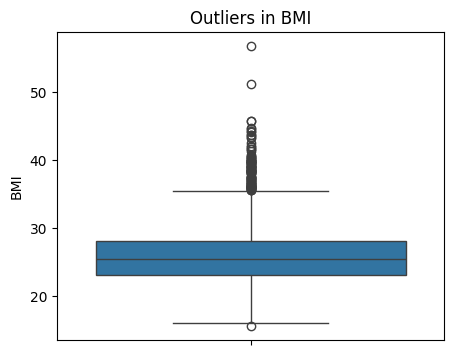

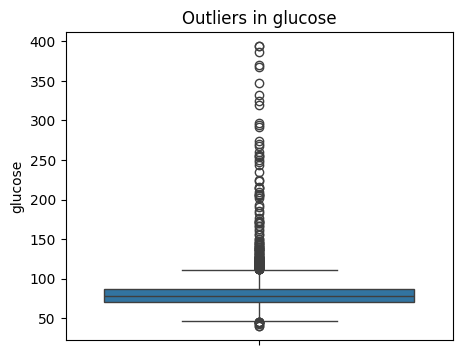

In [26]:
for col in ['sysBP','BMI','glucose']:
    plt.figure(figsize=(5,4))
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")
    plt.xlabel("")  # optional
    plt.ylabel(col)
    plt.show()

In [27]:
!pip install imbalanced-learn

In [28]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from collections import Counter

In [29]:
print("Before Resampling:", Counter(y_train))

Before Resampling: Counter({0: 2877, 1: 515})


In [30]:
# ==========================================
# SMOTE
# ==========================================
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_processed, y_train)

print("After SMOTE:", Counter(y_smote))


# ==========================================
# Borderline SMOTE
# ==========================================
bsmote = BorderlineSMOTE(random_state=42)
X_bsmote, y_bsmote = bsmote.fit_resample(X_train_processed, y_train)

print("After Borderline SMOTE:", Counter(y_bsmote))


# ==========================================
# ADASYN
# ==========================================
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_processed, y_train)

print("After ADASYN:", Counter(y_adasyn))

After SMOTE: Counter({0: 2877, 1: 2877})
After Borderline SMOTE: Counter({0: 2877, 1: 2877})
After ADASYN: Counter({1: 2962, 0: 2877})


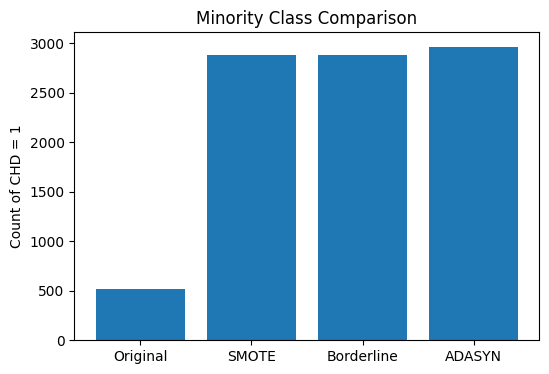

In [31]:
import matplotlib.pyplot as plt

labels = ['Original', 'SMOTE', 'Borderline', 'ADASYN']
counts = [
    Counter(y_train)[1],
    Counter(y_smote)[1],
    Counter(y_bsmote)[1],
    Counter(y_adasyn)[1]
]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.title("Minority Class Comparison")
plt.ylabel("Count of CHD = 1")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.neural_network import MLPClassifier

In [69]:
base_models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

In [35]:
advanced_models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

In [36]:
# Voting
voting = VotingClassifier(
    estimators=[
        ('rf', advanced_models["Random Forest"]),
        ('xgb', advanced_models["XGBoost"]),
        ('lgbm', advanced_models["LightGBM"])
    ],
    voting='soft'
)

# Stacking
stacking = StackingClassifier(
    estimators=[
        ('rf', advanced_models["Random Forest"]),
        ('xgb', advanced_models["XGBoost"]),
        ('lgbm', advanced_models["LightGBM"])
    ],
    final_estimator=LogisticRegression()
)

In [37]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300)

In [38]:
all_models = {
    **base_models,
    **advanced_models,
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "Voting Ensemble": voting,
    "Stacking Ensemble": stacking,
    "MLP (DL)": mlp
}


🔹 Training: Logistic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

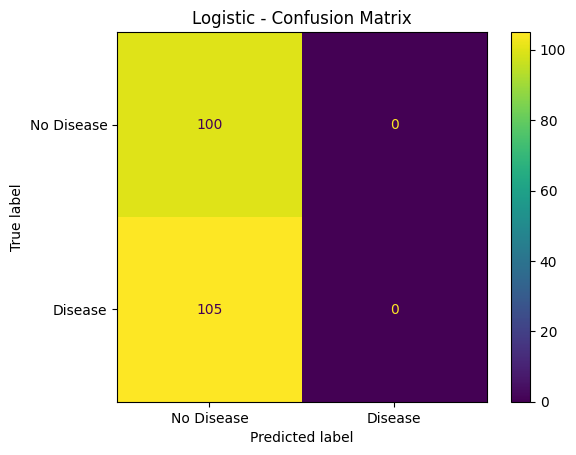

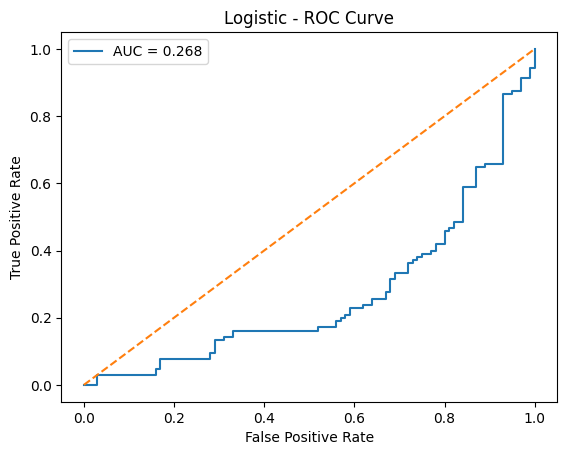


🔹 Training: SVM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

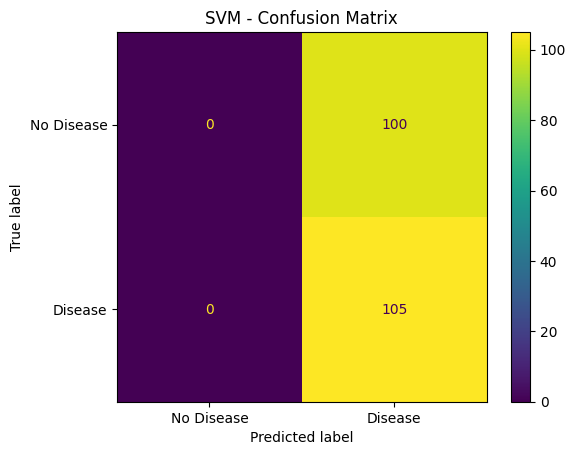

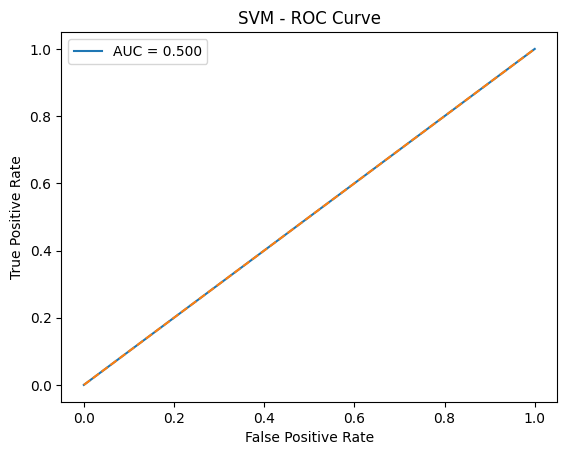


🔹 Training: KNN


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

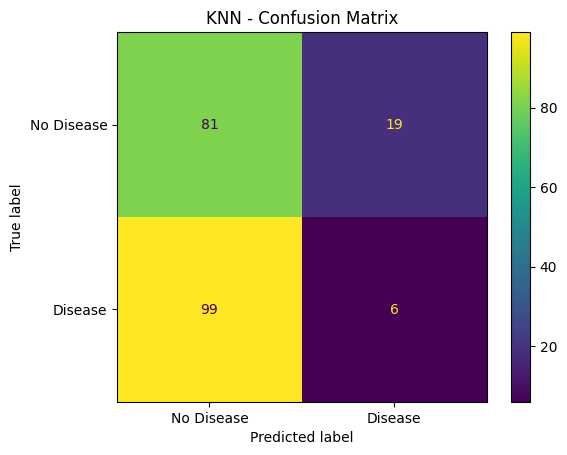

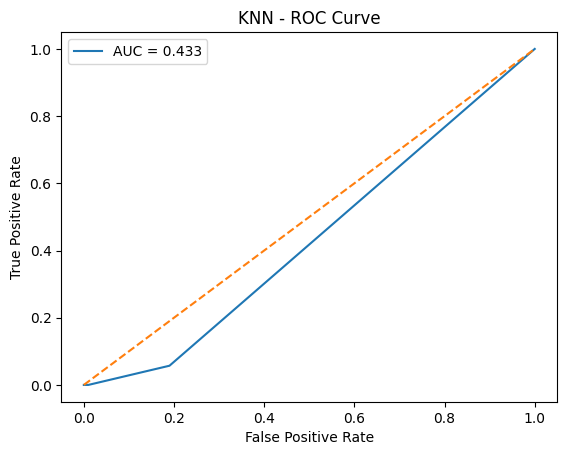


🔹 Training: Decision Tree


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

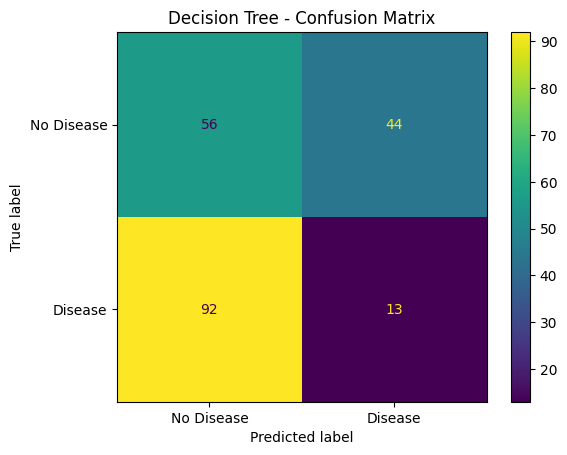

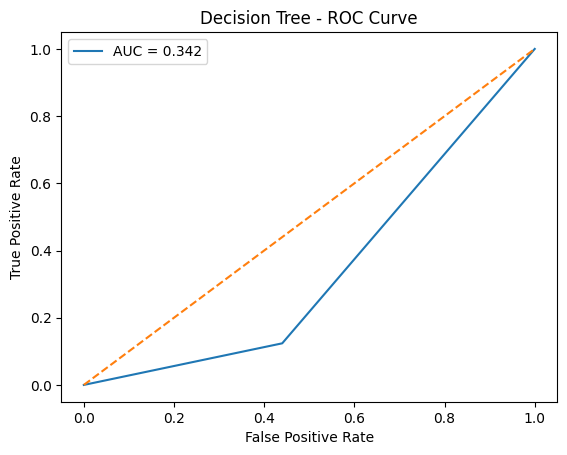


🔹 Training: Naive Bayes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

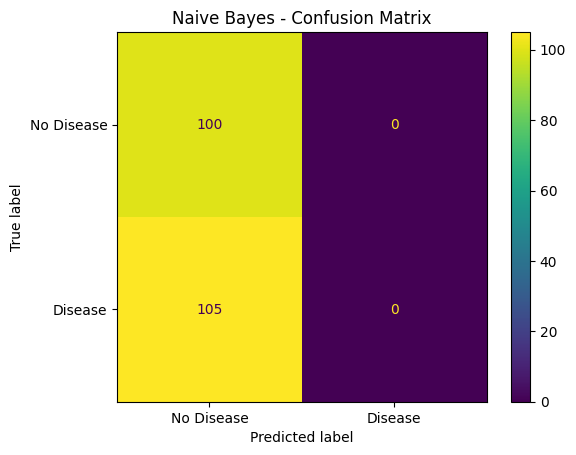

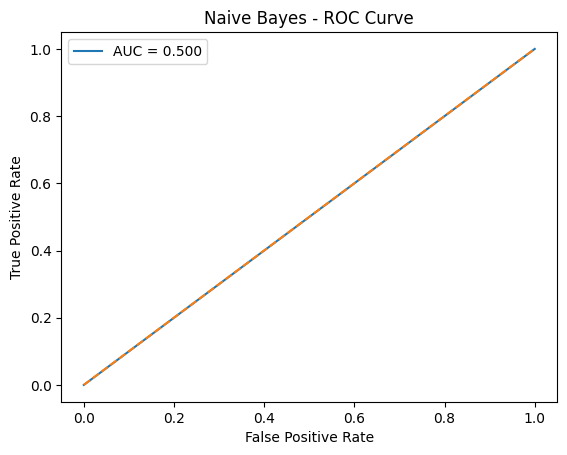


🔹 Training: Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

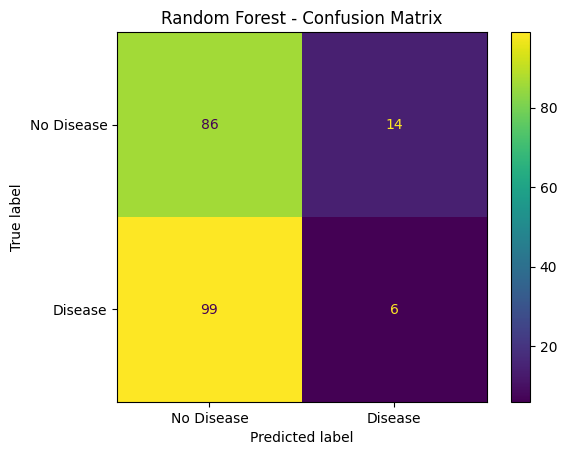

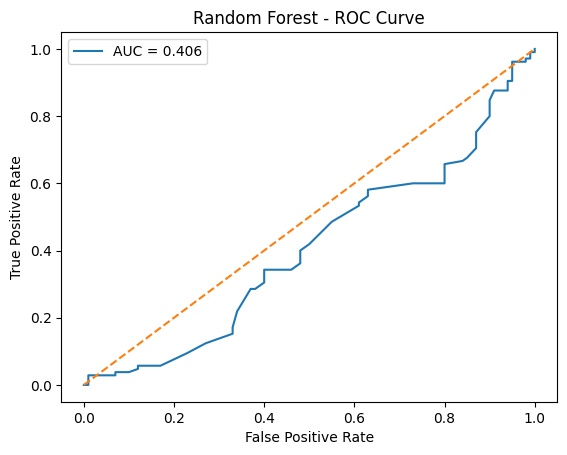


🔹 Training: Extra Trees


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

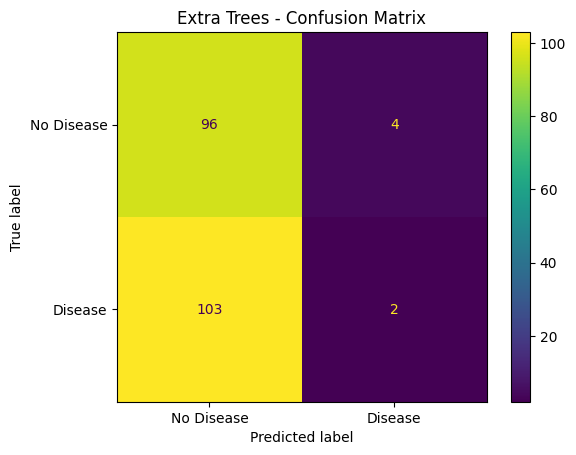

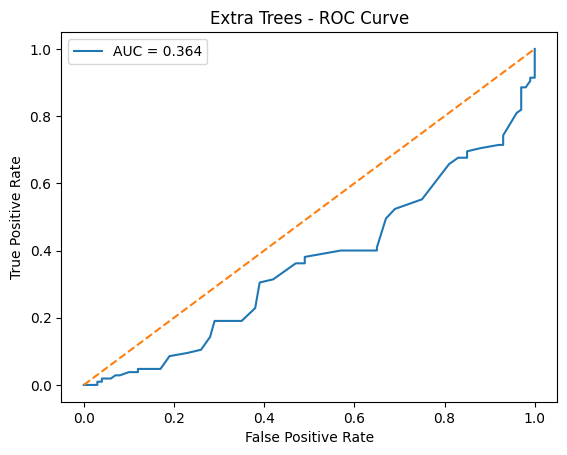


🔹 Training: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 640x480 with 0 Axes>

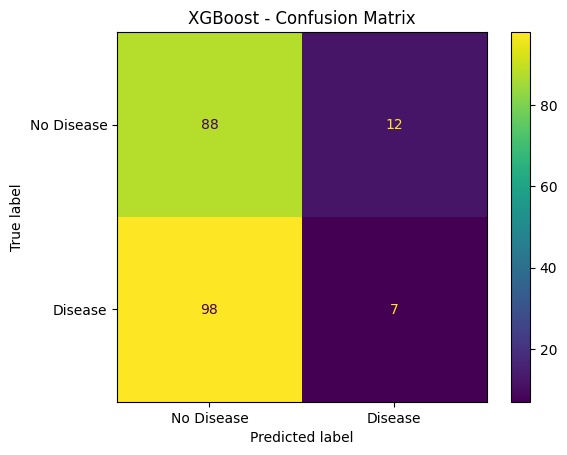

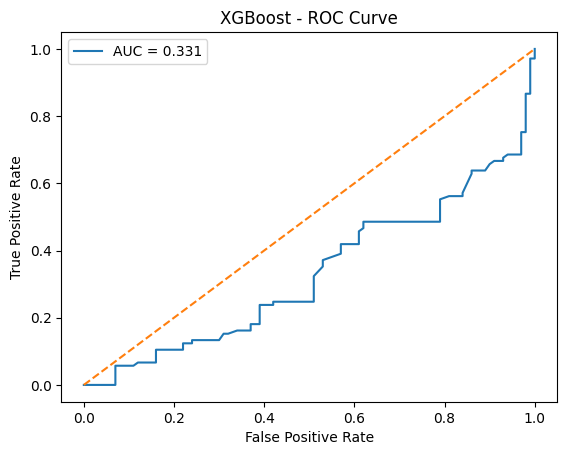


🔹 Training: LightGBM
[LightGBM] [Info] Number of positive: 1000, number of negative: 1000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1593
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


<Figure size 640x480 with 0 Axes>

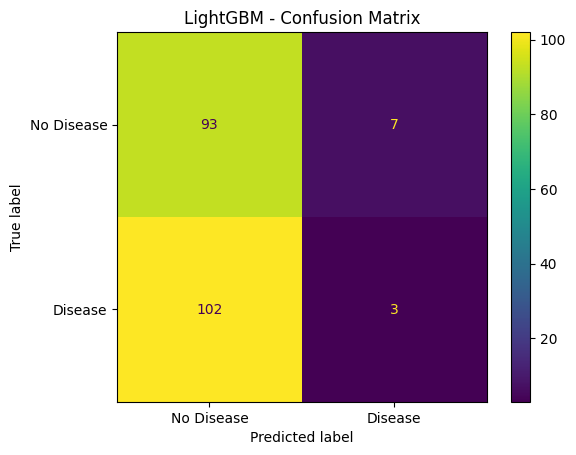

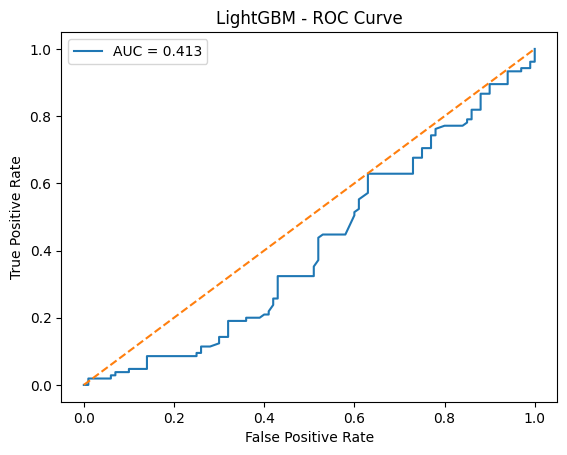


🔹 Training: AdaBoost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but AdaBoostClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but AdaBoostClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

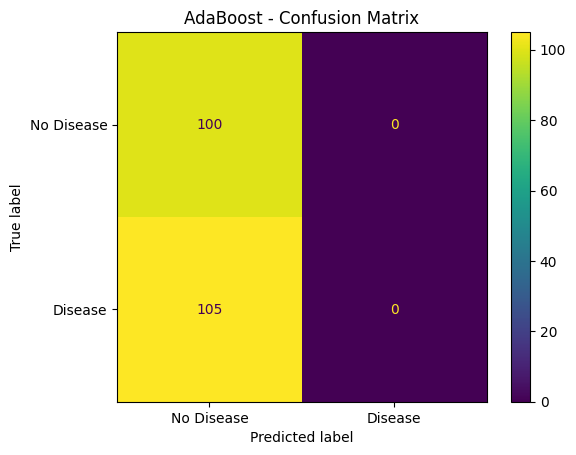

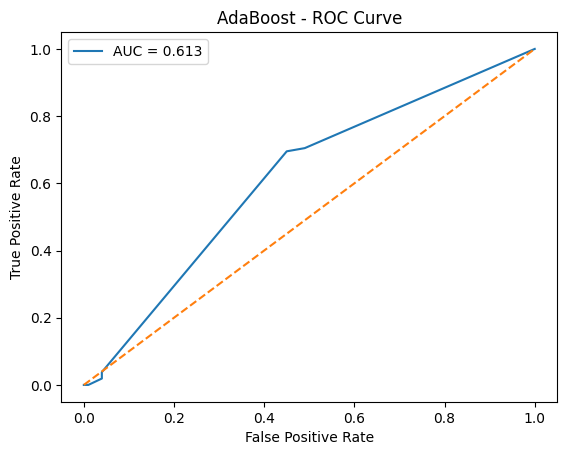


🔹 Training: Bagging


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

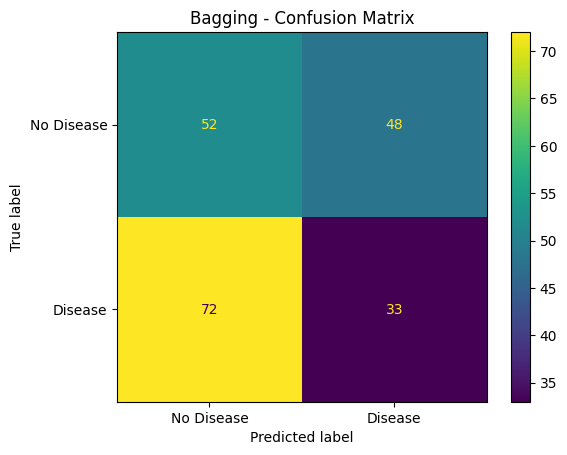

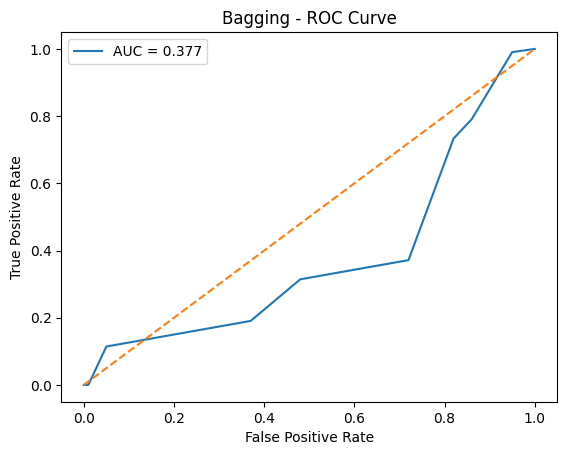


🔹 Training: Voting Ensemble


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1000, number of negative: 1000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000298 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1593
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

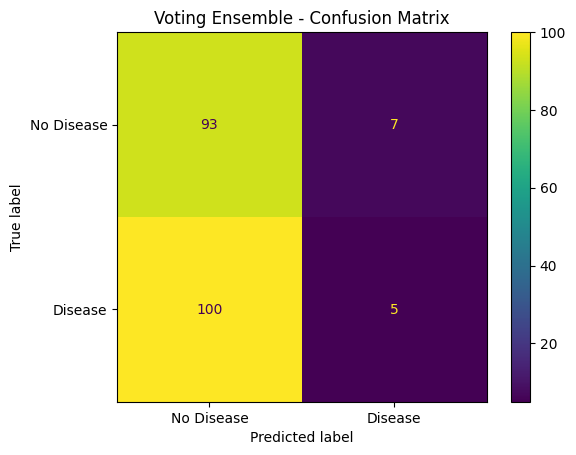

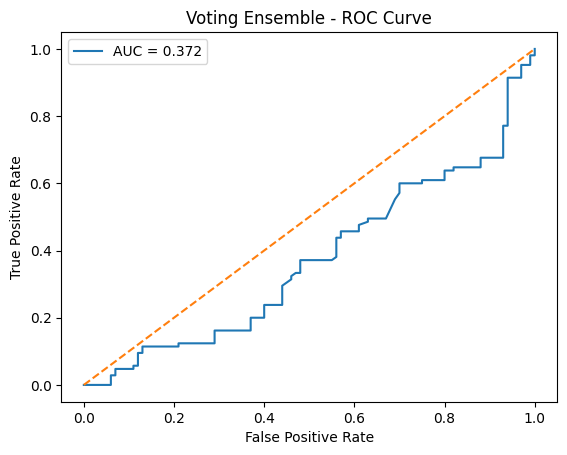


🔹 Training: Stacking Ensemble


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1000, number of negative: 1000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1593
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 800, number of negative: 800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1591
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 800, number of negative: 800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1599
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

[LightGBM] [Info] Number of positive: 800, number of negative: 800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1482
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 800, number of negative: 800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1481
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 800, number of negative: 800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1467
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

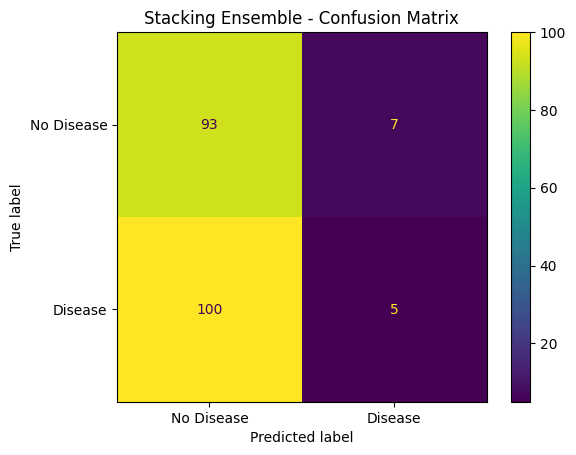

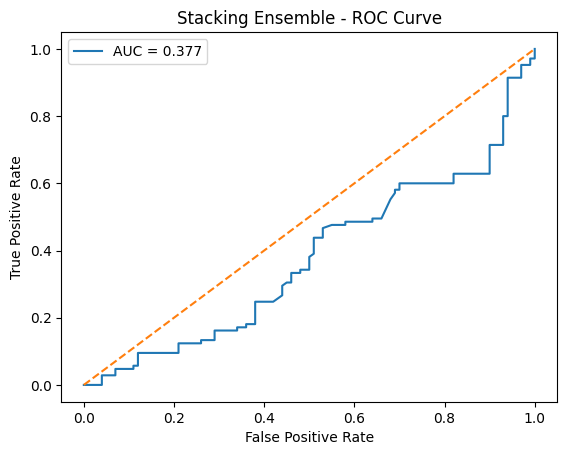


🔹 Training: MLP (DL)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

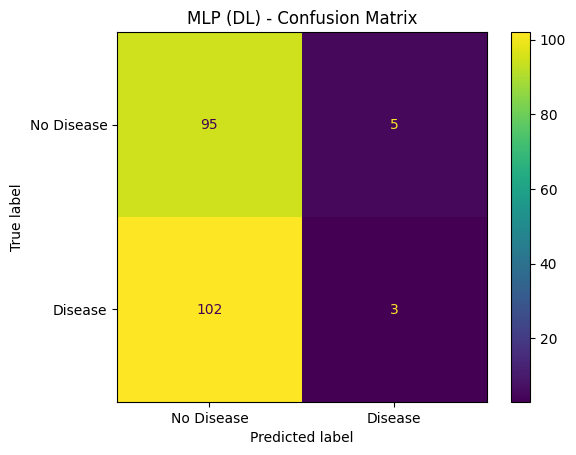

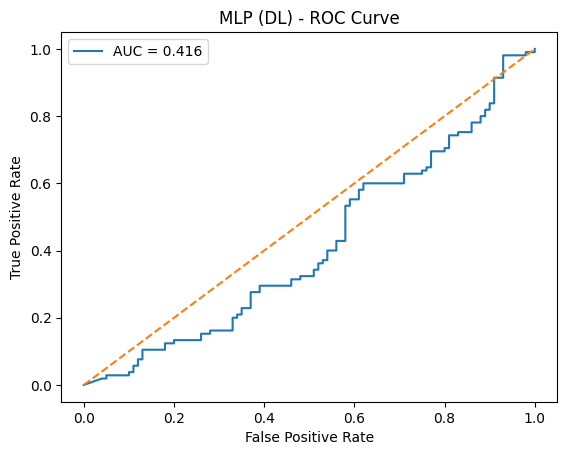


📊 AUC Scores:
Logistic: 0.2677
SVM: 0.5000
KNN: 0.4333
Decision Tree: 0.3419
Naive Bayes: 0.5000
Random Forest: 0.4059
Extra Trees: 0.3635
XGBoost: 0.3311
LightGBM: 0.4129
AdaBoost: 0.6133
Bagging: 0.3767
Voting Ensemble: 0.3718
Stacking Ensemble: 0.3770
MLP (DL): 0.4156


In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

results = {}

for name, model in all_models.items():
    print(f"\n🔹 Training: {name}")
    
    # 1. Train
    model.fit(X_train_res, y_train_res)
    
    # 2. Predict labels
    y_pred = model.predict(X_test)
    
    # 3. Predict probabilities (needed for AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    # 4. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure()
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    
    # 5. ROC Curve + AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.show()
    
    # 6. Store results
    results[name] = roc_auc

# 7. Print summary
print("\n📊 AUC Scores:")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

In [80]:
def evaluate_models(models, X_train, y_train, X_test, y_test):
    from sklearn.metrics import classification_report, roc_auc_score
    
    results = []
    
    for name, model in models.items():
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_processed)
        y_prob = model.predict_proba(X_test_processed)[:,1]
        
        auc = roc_auc_score(y_test, y_prob)
        print(f"\n{name}")
        print(classification_report(y_test, y_pred))
        print("AUC:", auc)
        
        results.append((name, auc))
        # 4. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure()
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    return results


Logistic
              precision    recall  f1-score   support

           0       0.89      0.77      0.82       100
           1       0.81      0.90      0.85       105

    accuracy                           0.84       205
   macro avg       0.85      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205

AUC: 0.9248571428571429

SVM
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       100
           1       0.93      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205

AUC: 0.978857142857143

KNN
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       100
           1       0.95      0.92      0.94       105

    accuracy                           0.94       205
   macro avg       0.94      0.94      0.94       205
weighte

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:57:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

AUC: 1.0

AdaBoost
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       100
           1       0.89      0.91      0.90       105

    accuracy                           0.90       205
   macro avg       0.90      0.90      0.90       205
weighted avg       0.90      0.90      0.90       205

AUC: 0.9447619047619048

Bagging
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:57:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1000, number of negative: 1000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1593
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 800, number of negative: 800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1467
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Stacking Ensemble
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

AUC: 1.0

MLP (DL)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

AUC: 1.0


<Figure size 640x480 with 0 Axes>

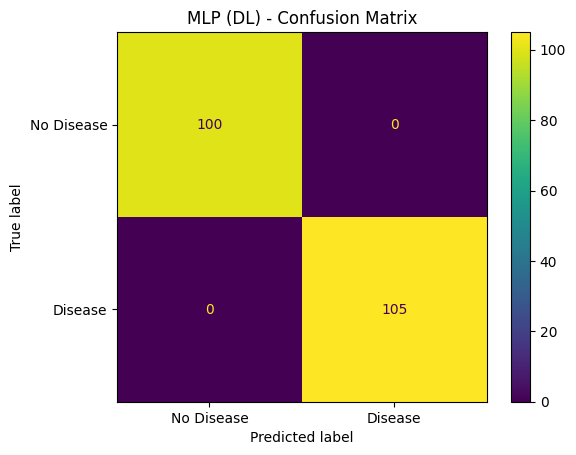

In [81]:
results_all = evaluate_models(
    all_models,
    X_train_res, y_train_res,
    X_test_processed, y_test
)

In [74]:
y_pred = models.predict(X_test)

NameError: name 'models' is not defined

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

NameError: name 'y_pred' is not defined